In [10]:
!python --version

Python 3.14.3


The system cannot find the path specified.


In [36]:
import gc
from PIL import Image

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from sam.segment_anything import SamPredictor, SamAutomaticMaskGenerator, build_sam_vit_h # glad it works with out of directory imports too :)
from utils import plot_predictions

from skimage import filters

In [15]:
model = SamAutomaticMaskGenerator(build_sam_vit_h(r"./bin/sam_vit_h_4b8939.pth"))

In [17]:
Image.open(r"./images/dog.jpg").mode

'RGB'

In [19]:
dog_pil = np.array(Image.open(r"./images/dog.jpg"), dtype=np.uint8)
dog_cv2 = cv2.imread(r"./images/dog.jpg")

In [20]:
(dog_pil == dog_cv2).mean()

np.float64(0.3448813982521848)

In [21]:
(dog_pil == cv2.cvtColor(dog_cv2, cv2.COLOR_BGR2RGB)).mean() # OpenCV reads in images in BGR colour channels by default but PIL uses RGB channel by default

np.float64(1.0)

In [22]:
masks_pil = model.generate(dog_pil)
masks_cv2 = model.generate(cv2.cvtColor(dog_cv2, cv2.COLOR_BGR2RGB))

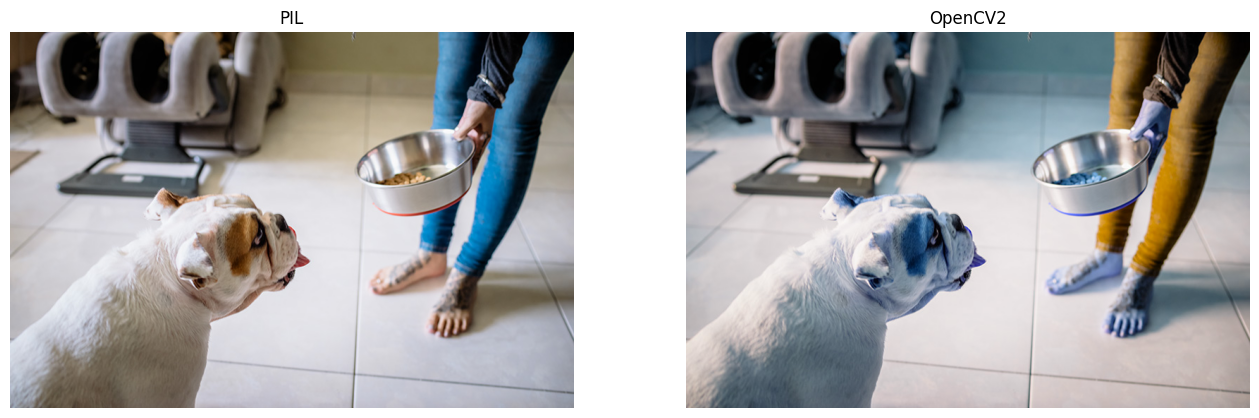

In [24]:
fig, (axis_l, axis_r) = plt.subplots(ncols=2)
fig.set_size_inches(8*2, 5)

axis_l.imshow(dog_pil)
axis_l.set_axis_off()
axis_l.set_title(r"PIL")

axis_r.imshow(dog_cv2)
axis_r.set_axis_off()
axis_r.set_title(r"OpenCV2")

plt.show()

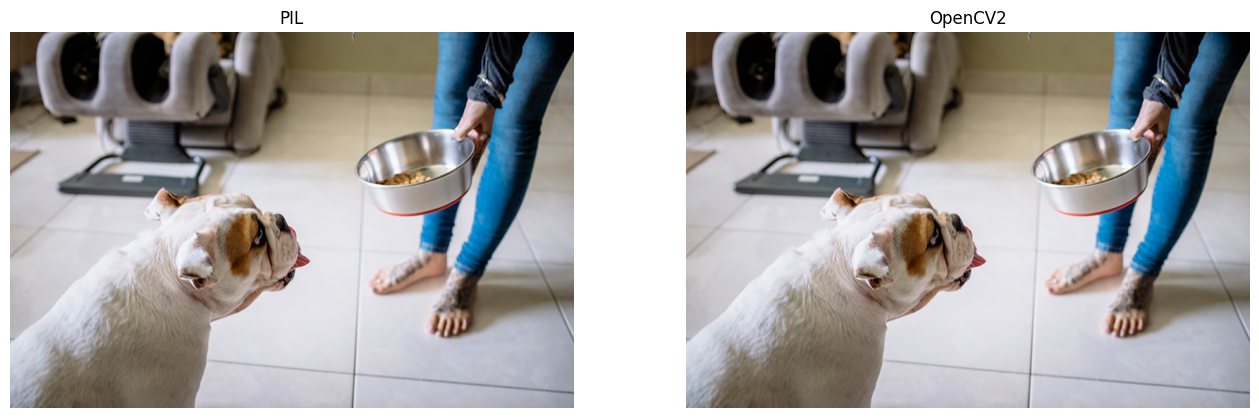

In [25]:
fig, (axis_l, axis_r) = plt.subplots(ncols=2)
fig.set_size_inches(8*2, 5)

axis_l.imshow(dog_pil)
axis_l.set_axis_off()
axis_l.set_title(r"PIL")

axis_r.imshow(cv2.cvtColor(dog_cv2, cv2.COLOR_BGR2RGB)) # with colour channel transformation
axis_r.set_axis_off()
axis_r.set_title(r"OpenCV2")

plt.show()

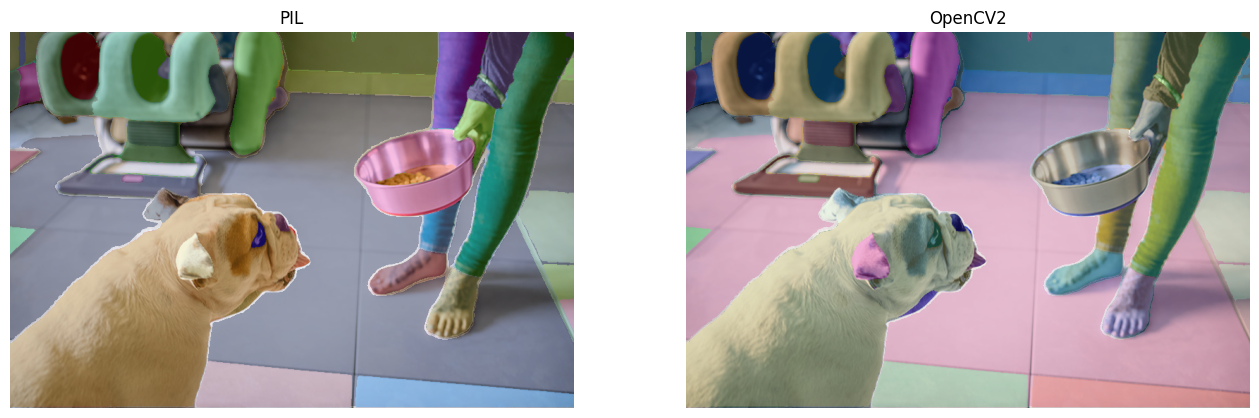

In [30]:
fig, (axis_l, axis_r) = plt.subplots(ncols=2)
fig.set_size_inches(8*2, 5)

axis_l.imshow(dog_pil)
axis_l.set_axis_off()
axis_l.set_title(r"PIL")
plot_predictions(masks_pil, axes=axis_l)

axis_r.imshow(dog_cv2)
axis_r.set_axis_off()
axis_r.set_title(r"OpenCV2")
plot_predictions(masks_cv2, axes=axis_r)

plt.show()

In [37]:
# try inspecting an individual boolean mask
boolean_mask = masks_cv2[0]["segmentation"]

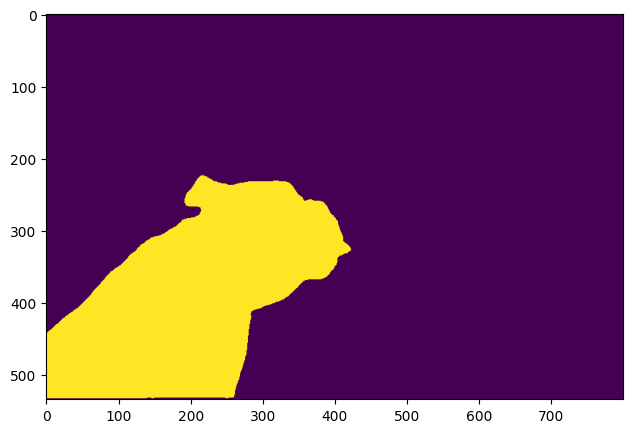

In [38]:
fig, axes = plt.subplots()
fig.set_size_inches(8, 5)
axes.imshow(boolean_mask)
plt.show()

In [48]:
bmask_roberts = filters.roberts(boolean_mask)
bmask_sobel = filters.sobel(boolean_mask)
bmask_scharr = filters.scharr(boolean_mask)

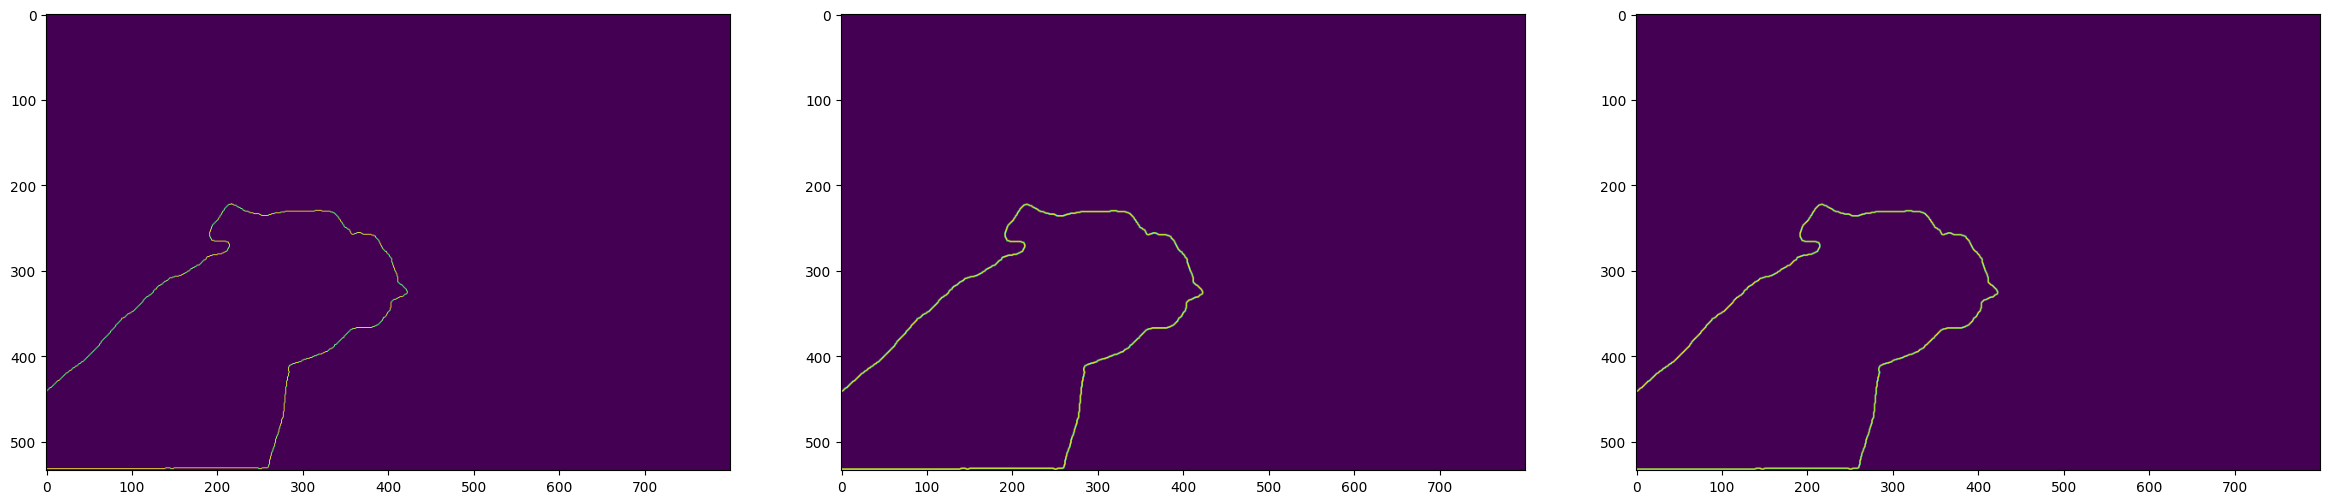

In [49]:
fig, (axes_0, axes_1, axes_2) = plt.subplots(ncols=3)
fig.set_size_inches(24, 5)
axes_0.imshow(bmask_roberts)
axes_1.imshow(bmask_sobel)
axes_2.imshow(bmask_scharr)
plt.tight_layout()
plt.show()